### Импорты

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Выгразка данных

In [10]:
path_dir_data = r"./data/data"
path_dir_submissions = r"./data/submit"

In [11]:
authors = pd.read_csv(path_dir_data + "/authors.csv")
book_genres = pd.read_csv(path_dir_data + "/book_genres.csv")
editions = pd.read_csv(path_dir_data + "/editions.csv")
genres = pd.read_csv(path_dir_data + "/genres.csv")
interactions = pd.read_csv(path_dir_data + "/interactions.csv")
users = pd.read_csv(path_dir_data + "/users.csv")

candidates = pd.read_csv(path_dir_submissions + "/candidates.csv")
example_submission = pd.read_csv(path_dir_submissions + "/example_submission.csv")
targets = pd.read_csv(path_dir_submissions + "/targets.csv")

### Первая проверка данных

#### Authors

In [13]:
authors.head()

,author_id,author_name
0,1,Грегори Бенфорд
1,6,Вячеслав Маркин
2,18,Эдвард де Боно
3,19,Василий Головачёв
4,21,Пауло Коэльо


#### Book_genres

In [16]:
book_genres.head()

,book_id,genre_id
0,20,433
1,20,1217
2,35,141
3,35,142
4,35,146


#### Genres

In [19]:
genres.head()

,genre_id,genre_name
0,1,Бизнес-книги
1,2,Банковское-дело
2,3,Бухучет-налогообложение-аудит
3,4,Государственное-и-муниципальное-управление
4,5,Делопроизводство


In [22]:
genres["genre_name"].value_counts().sort_values(ascending=False)

genre_name
Бизнес-книги                                  1
Банковское-дело                               1
Бухучет-налогообложение-аудит                 1
Государственное-и-муниципальное-управление    1
Делопроизводство                              1
                                             ..
Психологический-роман                         1
Славянское-фэнтези                            1
Ориентальное-фэнтези                          1
Вебтун                                        1
unknown                                       1
Name: count, Length: 586, dtype: int64

In [23]:
genres.info()

<class 'pandas.DataFrame'>
RangeIndex: 586 entries, 0 to 585
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   genre_id    586 non-null    int64
 1   genre_name  586 non-null    str  
dtypes: int64(1), str(1)
memory usage: 9.3 KB


In [26]:
for name in genres["genre_name"].tolist():
    mass = name.split(";")
    if len(mass) > 1:
        print(name)

#### Users

In [27]:
users.head()

,user_id,gender,age
0,560,2.0,9.0
1,3410,2.0,39.0
2,5620,1.0,42.0
3,5700,2.0,40.0
4,6120,2.0,32.0


In [28]:
users["gender"].value_counts()

gender
2.0    4311
1.0     585
Name: count, dtype: int64

In [29]:
users["age"].value_counts()

age
25.0    264
30.0    246
35.0    244
31.0    234
33.0    230
       ... 
77.0      1
99.0      1
72.0      1
87.0      1
6.0       1
Name: count, Length: 74, dtype: int64

Text(0.5, 1.0, 'Распределение по возрасту')

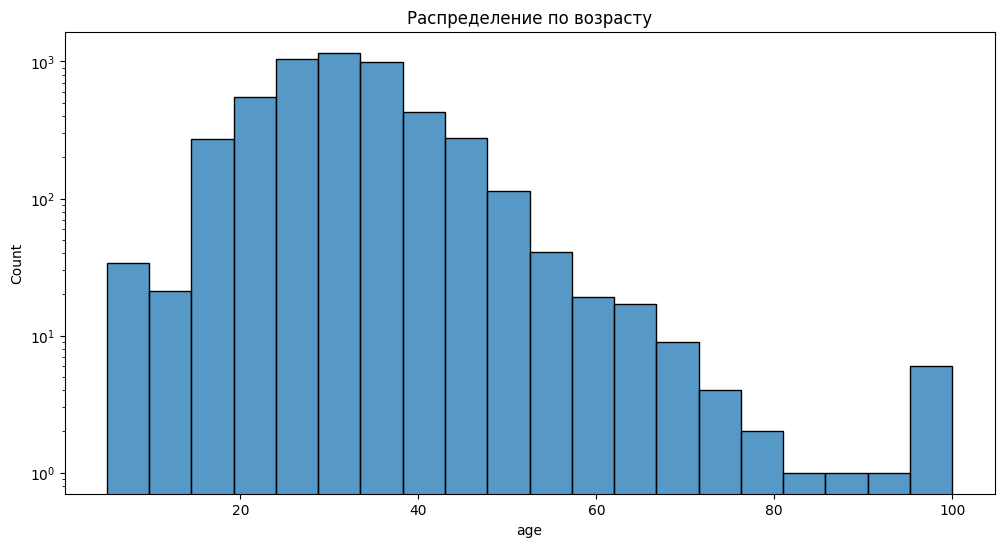

In [34]:
plt.figure(figsize=(12, 6))
sns.histplot(x="age", data=users, bins=20)
plt.yscale("log")
plt.title("Распределение по возрасту")

#### Editions

In [35]:
editions.head()

,edition_id,book_id,author_id,publication_year,age_restriction,language_id,publisher_id,title,description
0,1000000001,1093185,1.0,2000,18,119,9,Панорама времен,"Научный фантаст - тот, кто не стыдится первой ..."
1,1000000016,1548860,18.0,2005,16,119,1276,Развитие мышления: три пятидневных курса,"Талантливый ученый с мировым именем, изобретат..."
2,1000000020,20,21.0,2005,16,119,432,Вероника решает умереть,"Вторая изданная ""Софией"" книга Коэльо - совсем..."
3,1000000035,35,33.0,2002,18,119,122,Самое жуткое приключение,Когда Ларри Бойд и его друзья решили применить...
4,1000000070,891990,226891.0,2001,12,119,9,Танцы на снегу,«Звездные войны» от Сергея Лукьяненко? Да.\r\n...


In [37]:
editions.info()

<class 'pandas.DataFrame'>
RangeIndex: 134231 entries, 0 to 134230
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   edition_id        134231 non-null  int64  
 1   book_id           134231 non-null  int64  
 2   author_id         134231 non-null  float64
 3   publication_year  134231 non-null  int64  
 4   age_restriction   134231 non-null  int64  
 5   language_id       134231 non-null  int64  
 6   publisher_id      134231 non-null  int64  
 7   title             134231 non-null  str    
 8   description       126176 non-null  str    
dtypes: float64(1), int64(6), str(2)
memory usage: 9.2 MB


#### Interactions

In [36]:
interactions.head()

,user_id,edition_id,event_type,rating,event_ts
0,560,1012411658,2,6.0,2024-12-24 19:02:14
1,560,1008465904,2,6.0,2025-01-10 19:18:04
2,560,1001243738,2,10.0,2025-01-25 11:28:11
3,560,1009492501,2,8.0,2025-01-25 11:28:42
4,560,1000118974,2,8.0,2025-03-10 18:14:17


In [38]:
interactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 231210 entries, 0 to 231209
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     231210 non-null  int64  
 1   edition_id  231210 non-null  int64  
 2   event_type  231210 non-null  int64  
 3   rating      125369 non-null  float64
 4   event_ts    231210 non-null  str    
dtypes: float64(1), int64(3), str(1)
memory usage: 8.8 MB


In [39]:
interactions["user_id"].nunique()

5067

In [43]:
interactions["event_type"].value_counts()

event_type
2    146659
1     84551
Name: count, dtype: int64

In [45]:
interactions["user_id"].value_counts().sort_values(ascending=False)

user_id
1310260     290
4720390     288
5718550     288
1707730     287
11053490    287
           ... 
11802880      5
11811760      5
11867050      5
11903710      5
11940280      5
Name: count, Length: 5067, dtype: int64

In [46]:
interactions["event_ts"].min(), interactions["event_ts"].max()

('2024-10-14 18:48:56', '2025-04-12 12:44:23')

#### Небольшая склейка, хочу проверить могут ли читать дети недостигшие возраста книги

In [47]:
interactions_editions = interactions.merge(editions, on="edition_id", how="left")
iter_users_editions = interactions_editions.merge(users, on="user_id", how="left")
iter_users_editions.head()

,user_id,edition_id,event_type,rating,event_ts,book_id,author_id,publication_year,age_restriction,language_id,publisher_id,title,description,gender,age
0,560,1012411658,2,6.0,2024-12-24 19:02:14,8387168,1085990.0,2024,16,119,123745,И время остановилось,"Во французском Берри, краю замков и зеленых по...",2.0,9.0
1,560,1008465904,2,6.0,2025-01-10 19:18:04,6064826,2338126.0,2023,16,119,1470,Смерть и круассаны,"Ричард Эйнсворт — хозяин небольшой гостиницы, ...",2.0,9.0
2,560,1001243738,2,10.0,2025-01-25 11:28:11,1047228,11528.0,1984,16,119,1016,Evgenia Ivanovna,"Повесть Леонида Леонова, одного из крупнейших ...",2.0,9.0
3,560,1009492501,2,8.0,2025-01-25 11:28:42,6763729,2355.0,0,18,119,7,Transhumanism inc. + KGBT+,В комплект вошли два известных романа Виктора ...,2.0,9.0
4,560,1000118974,2,8.0,2025-03-10 18:14:17,127995,123194.0,2005,18,119,33,Тьма на ладони,"...Рекламный ролик, снятый 20 лет назад, в одн...",2.0,9.0


In [50]:
iter_users_editions[["age_restriction", "age"]].head()

,age_restriction,age
0,16,9.0
1,16,9.0
2,16,9.0
3,18,9.0
4,18,9.0


Сразу видим, что возрастные ограничения не играют роли